In [1]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import harmonica as hm
import invlinear

Text(0.5, 0, 'Coordenada horizontal (m)')

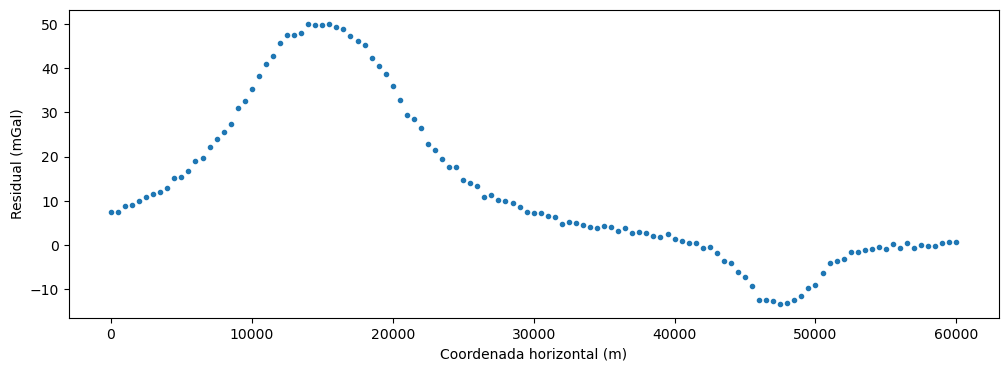

In [4]:
# Gera dados ao longo de um perfil
x = vd.line_coordinates(0, 60e3, spacing=500)
coordinates = (x, np.zeros_like(x), np.full_like(x, 0))

# Cria um modelo sintético com prismas
model = [
    [10e3, 20e3, -100e3, 100e3, -8e3, -3e3],
    [45e3, 50e3, -100e3, 100e3, -3e3, -1e3],
]
density = [500, -300]  # kg/m³
gravity = hm.prism_gravity(coordinates, prisms=model, density=density, field="g_z")

# Contamina os dados com ruído aleatório
gravity += np.random.normal(0, 0.5, size=gravity.size)

plt.figure(figsize=(12, 4))
plt.plot(x, gravity, ".")
plt.ylabel("Residual (mGal)")
plt.xlabel("Coordenada horizontal (m)")

(<Figure size 1000x600 with 3 Axes>,
 array([<Axes: >, <Axes: xlabel='horizontal', ylabel='upward'>],
       dtype=object))

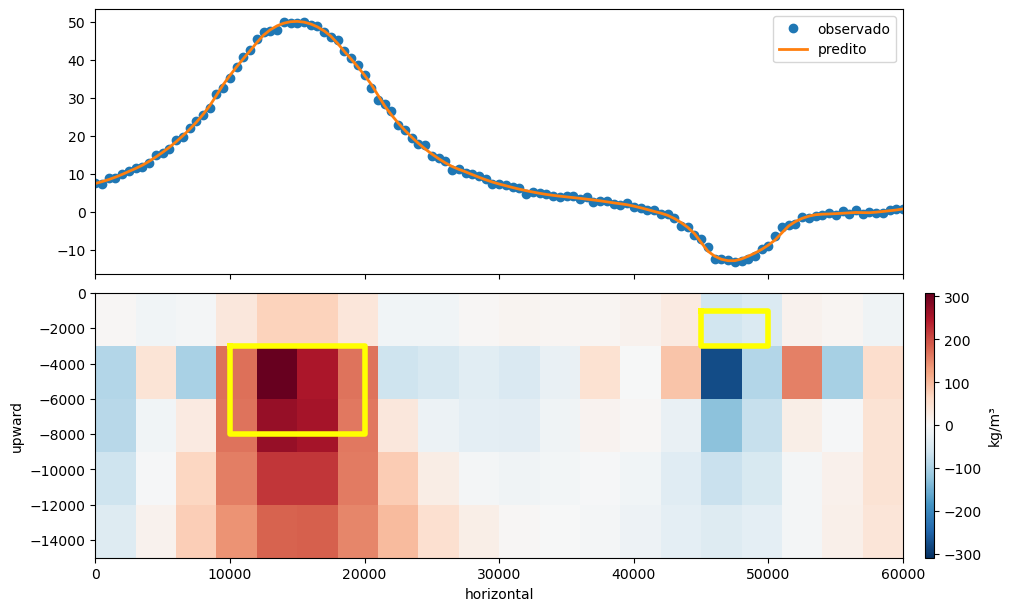

In [8]:
mesh, predicted = invlinear.inversao_linear(
    coordinates, 
    gravity,
    tamanho_celula=3000,
    damping=5e-5,
    potencia=1,
)
invlinear.plota_modelo(x, gravity, model, predicted, mesh)